# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and UMAP
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

In [1]:
# Add scripts directory to path
import sys
from pathlib import Path
import importlib

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Reload modules to pick up any changes
importlib.reload(device_utils)
importlib.reload(profiling)
importlib.reload(data_ingestion)
importlib.reload(fe)
importlib.reload(model_utils)
importlib.reload(evaluation)
importlib.reload(visualization)

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported and reloaded successfully")


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All modules imported and reloaded successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = cfg.XGB_RANDOM_SEARCH_ITERS  # 80 iterations by default

# Data paths (relative to data directory)
NEWS_PATH = "../data/german_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 7.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)

✓ Using device: Apple MPS GPU
  Optimal batch size: 128


## 4. Stage 1: Data Ingestion

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=600,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (600, 4)
Energy telemetry shape: (8926, 5)
Baseline feature frame: (8734, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 0.72s
  CPU usage: 26.3% • IO wait: 0.00%
  Disk Δ: +51.8 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Data loaded successfully
  News articles: 600
  Energy records: 8926
  Master records: 8734


### Inspect Data

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    3226
 1.0    3202
 0.0    2306
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    36.936112
 1.0    36.661324
 0.0    26.402565
Name: proportion, dtype: float64


In [6]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    embedding_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        batch_size=device_config['optimal_batch_size'],
        model_name=cfg.ZEROSHOT_MODEL,
        hierarchical_topic_groups=cfg.HIERARCHICAL_TOPIC_GROUPS,
        routing_settings=cfg.HIERARCHICAL_ROUTING_SETTINGS,
    )

news_df = embedding_results['news_df']

print(f"\n✓ Topic classification completed")
print(f"  Device used: {embedding_results['hf_device']}")
print(f"  Batch size: {embedding_results['batch_size']}")
if 'classification_stage1' in news_df.columns:
    print(f"  Stage-1 categories detected: {news_df['classification_stage1'].nunique()}")


[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


Device set to use mps


Processing 600 texts with batch_size=128
Processing 51 texts with batch_size=128
Processing 17 texts with batch_size=128
Processing 159 texts with batch_size=128
Processing 72 texts with batch_size=128
Processing 5 texts with batch_size=128
Processing 10 texts with batch_size=128
Processing 286 texts with batch_size=128
Processing 30 texts with batch_size=128
Processing 49 texts with batch_size=128
Processing 36 texts with batch_size=128
Processing 12 texts with batch_size=128
Processing 2 texts with batch_size=128
Classification completed: 600 articles processed
Articles classified as 'other': 157 (26.2%)

Classification distribution:
classification
kein Bezug zu Energie, Wetter oder Finanzmärkten                                     157
geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken      127
geopolitische Spannungen oder Sanktionen verschärfen die Energieversorgung            81
steigende Zinsen oder hohe Inflation verschärfen die Marktlage            

## 6. Stage 2B: Sentence Embeddings

In [7]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting
Loaded embeddings from cache (../outputs/.cache/embeddings/news_embeddings.parquet)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 0.09s
  CPU usage: 40.3% • IO wait: 0.00%
  Disk Δ: +23.4 MB read, +0.5 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Embeddings computed
  Embedding dimension: 384


# Plot comprehensive EDA dashboard

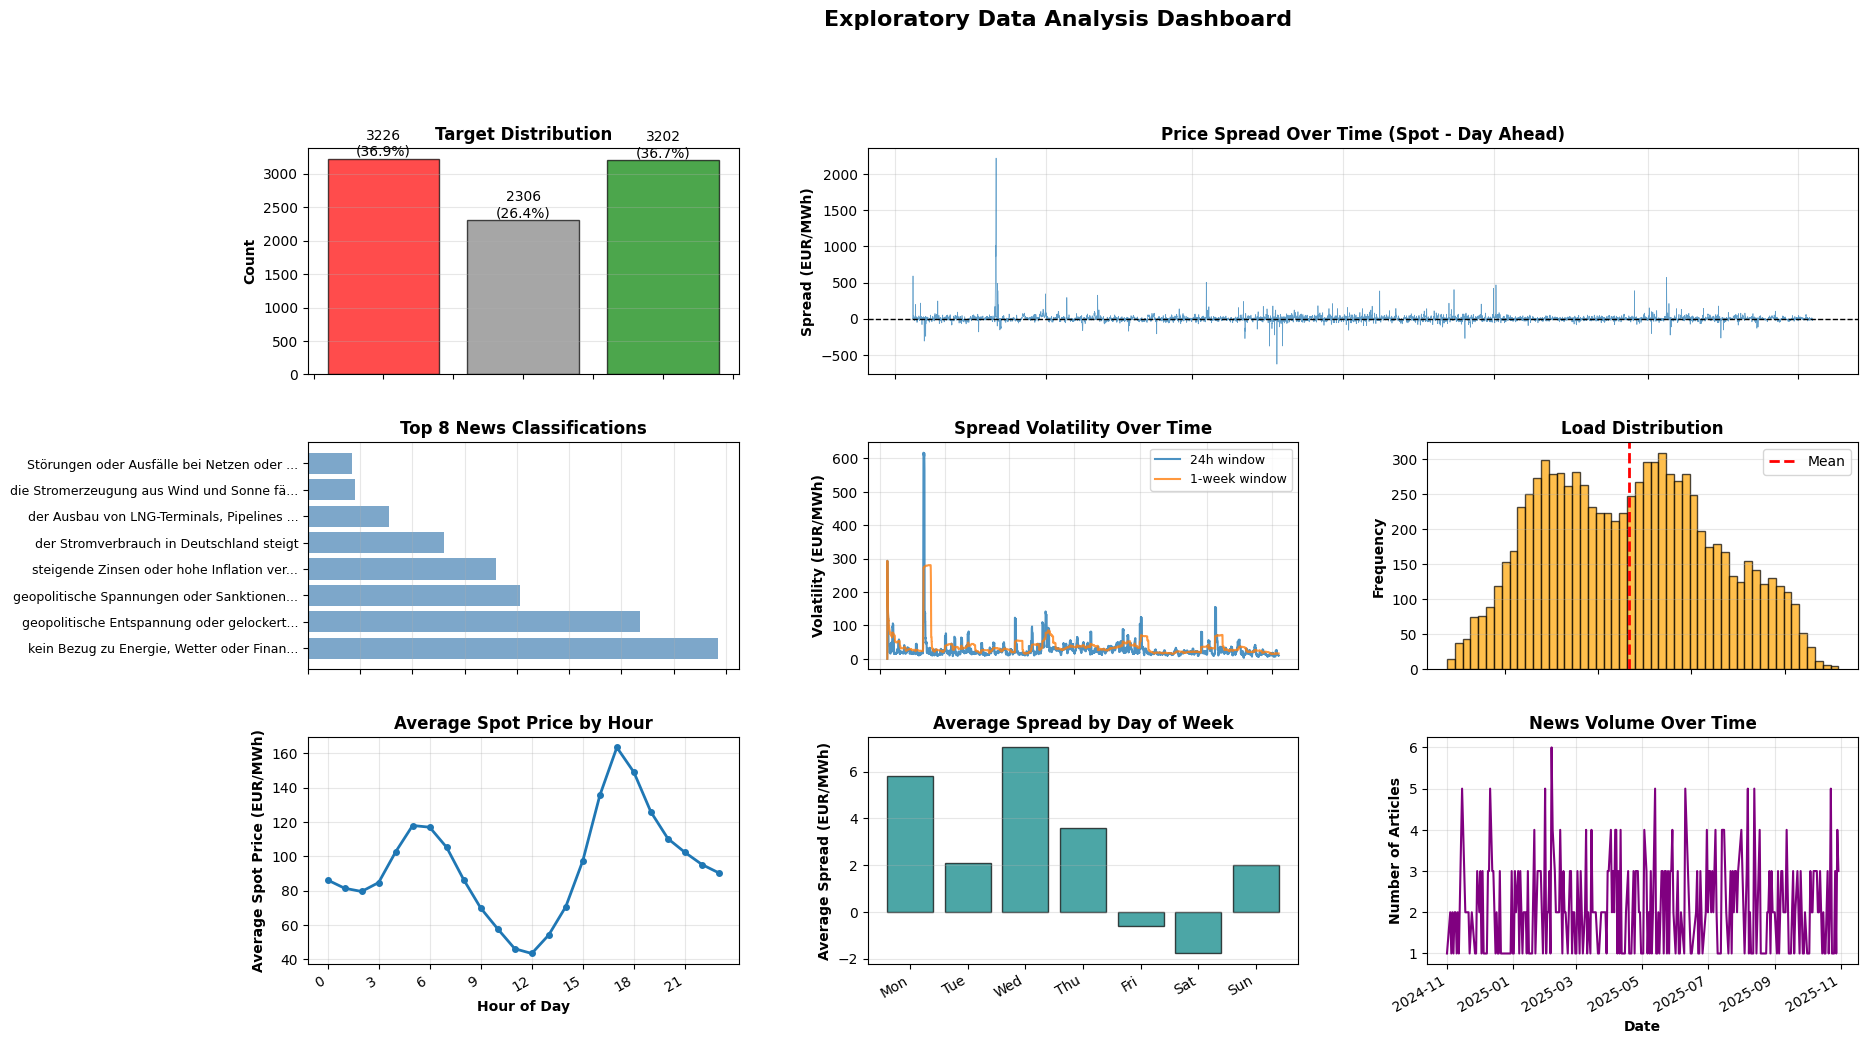

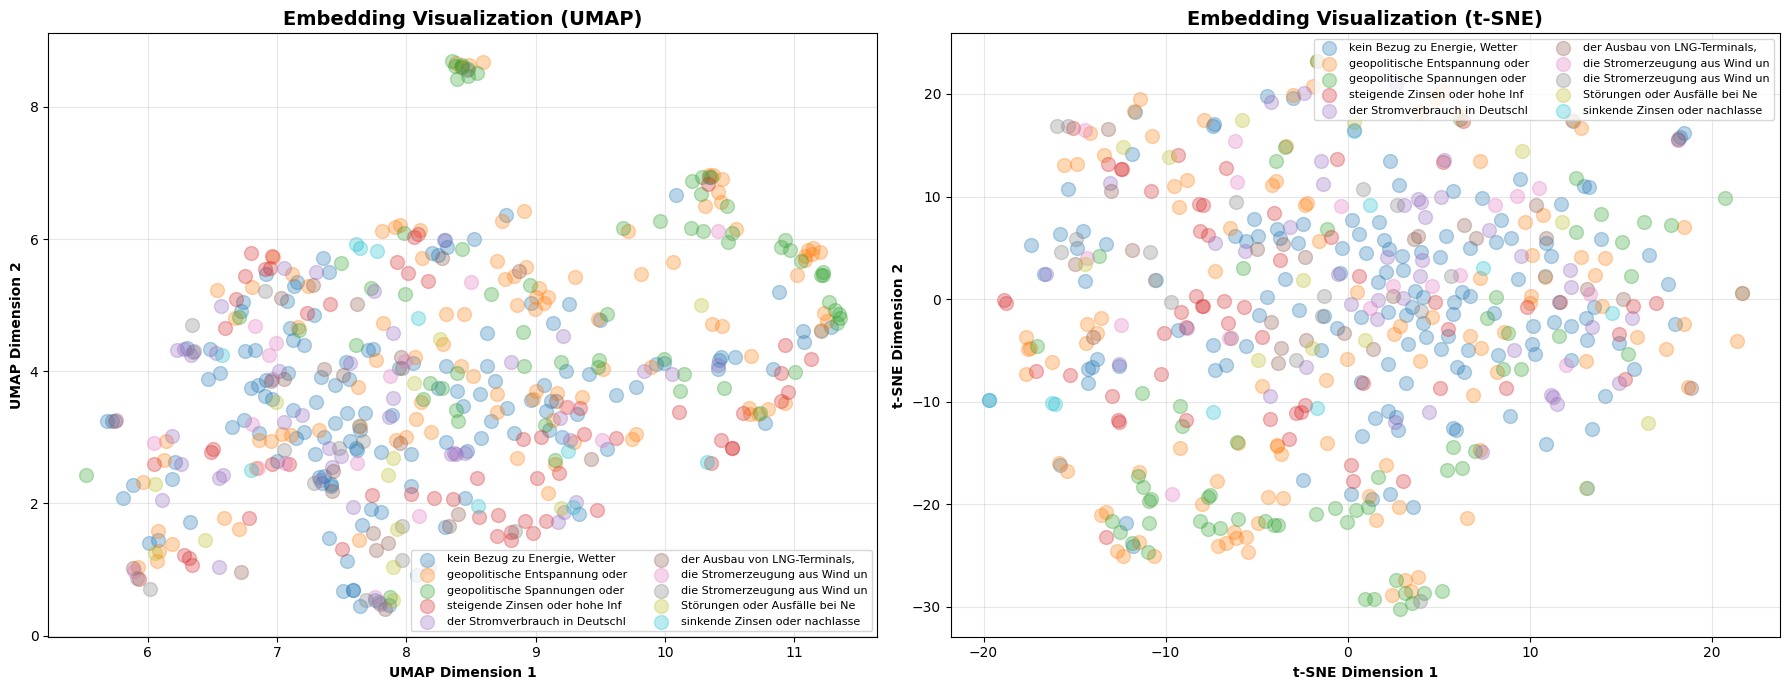

In [8]:
visualization.plot_eda_dashboard(master_df=master_df,news_df=news_df)
visualization.plot_embedding_quality(news_df=news_df, n_samples=500, perplexity=30)

## 7. Stage 3: Feature Engineering - Time-Decay Aggregation

In [9]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 30 parameter combinations...
Parallelizing across parameter combinations using joblib (n_jobs=-1)...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.5_reduction.parquet)


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   14.2s


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.5_reduction.parquet)


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   14.9s


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.25_reduction.parquet)


[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:   15.7s remaining:    9.1s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:   15.8s remaining:    4.8s


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.5_reduction.parquet)

✓ Completed precomputation of 30 parameter combinations
[Stage ✅] Stage 3A: Time-Decay Feature Precomputation — completed in 16.30s
  CPU usage: 83.4% • IO wait: 0.00%
  Disk Δ: +1164.8 MB read, +2679.4 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Time-decay feature cache built
  Parameter combinations: 30
  Sample keys: [(24, 0.01), (24, 0.05), (24, 0.1)]

[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:   16.2s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   16.3s finished


In [10]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        test_ratio=TEST_RATIO,
        dataset_prefix="td_dataset",
    )

sample_params_key = next(iter(preprocessed_datasets))
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Prepared datasets: {len(preprocessed_datasets)}")
print(
    f"  Sample dataset: {sample_dataset['dataset_name']} -> "
    f"train={len(sample_dataset['train_df'])}, "
    f"val={len(sample_dataset['val_df'])}, "
    f"test={len(sample_dataset['test_df'])}"
)


[Stage ⏳] Stage 3B: Dataset Assembly — starting
[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.09s
  CPU usage: 55.7% • IO wait: 0.00%
  Disk Δ: +0.8 MB read, +76.4 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset assembly complete
  Prepared datasets: 30
  Sample dataset: td_dataset_lw24_dl0.01 -> train=6113, val=1746, test=875


## 8. Stage 3C: Dataset Scaling & Summary

In [11]:
with profiling.StageProfiler("Stage 3C: Dataset Scaling", device_config):
    preprocessed_datasets = fe.scale_preprocessed_datasets(preprocessed_datasets)

sample_dataset = preprocessed_datasets[sample_params_key]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"\n✓ Dataset scaling complete")
print(f"  Scaled news features per dataset: {len(scaled_news_features)}")
print(f"  Sample scaled features: {scaled_news_features[:5]}")


[Stage ⏳] Stage 3C: Dataset Scaling — starting
[Stage ✅] Stage 3C: Dataset Scaling — completed in 0.30s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +1.4 MB read, +237.0 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset scaling complete
  Scaled news features per dataset: 34
  Sample scaled features: ['der Ausbau von LNG-Terminals, Pipelines oder Kraftwerken erhöht das Angebot_scaled', 'der Stromverbrauch in Deutschland steigt_scaled', 'Störungen oder Ausfälle bei Netzen oder Kraftwerken verringern das Angebot_scaled', 'geopolitische Spannungen oder Sanktionen verschärfen die Energieversorgung_scaled', 'geopolitische Entspannung oder gelockerte Sanktionen mindern Versorgungsrisiken_scaled']


## 9. Stage 3D: Feature Selection with RidgeCV

In [12]:
# Define baseline features for XGBoost and upstream stages
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168", "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# Restrict LightGBM baseline inputs to price-only spread signals
lgbm_baseline_features = [
    "real_spread_abs",
    "Day Ahead Auction",
    "Spot Price",
]

# Get news feature definitions from sample dataset
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline: {len(baseline_features)}, Topics: {len(topic_features)}, Embeddings: {len(embedding_features)}, Total news: {len(news_features)}")

# Run Ridge feature selection across parameter combinations
with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_5_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_5_combinations:
    best_params_key = top_5_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(f"\n✓ Top parameter combination: {best_dataset['dataset_name']} (lookback={top_5_combinations[0]['lookback_window']}h, lambda={top_5_combinations[0]['decay_lambda']})")
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline: 13, Topics: 14, Embeddings: 20, Total news: 34

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 30 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:    1.7s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:    2.0s remaining:    0.6s


TOP 5 PARAMETER COMBINATIONS:
1. dataset=td_dataset_lw168_dl0.5 | lookback=168h | lambda=0.5 | alpha=316.2278 | Val Accuracy=0.404 | Val Macro-F1=0.355
2. dataset=td_dataset_lw336_dl0.01 | lookback=336h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.403 | Val Macro-F1=0.364
3. dataset=td_dataset_lw168_dl0.01 | lookback=168h | lambda=0.01 | alpha=1000.0000 | Val Accuracy=0.402 | Val Macro-F1=0.361
4. dataset=td_dataset_lw72_dl0.01 | lookback=72h | lambda=0.01 | alpha=100.0000 | Val Accuracy=0.402 | Val Macro-F1=0.353
5. dataset=td_dataset_lw72_dl0.05 | lookback=72h | lambda=0.05 | alpha=3.1623 | Val Accuracy=0.402 | Val Macro-F1=0.349
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 2.39s
  CPU usage: 89.4% • IO wait: 0.00%
  Disk Δ: +34.0 MB read, +47.9 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Top parameter combination: td_dataset_lw168_dl0.5 (lookback=168h, lambda=0.5)


[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:    2.3s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    2.4s finished


## 10. Stage 3E: Summarise Ridge Results

In [13]:
# Display top 5 Ridge parameter combinations
if top_5_combinations:
    top_5_summary = pd.DataFrame([{
        "dataset_name": res["dataset_name"],
        "lookback_window": res["lookback_window"],
        "decay_lambda": res["decay_lambda"],
        "alpha": res["best_alpha"],
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
    } for res in top_5_combinations])
    display(top_5_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,td_dataset_lw168_dl0.5,168,0.50,316.227766,0.403780,0.354888
1,td_dataset_lw336_dl0.01,336,0.01,1000.000000,0.402635,0.364490
2,td_dataset_lw168_dl0.01,168,0.01,1000.000000,0.402062,0.360635
3,td_dataset_lw72_dl0.01,72,0.01,100.000000,0.402062,0.353193
4,td_dataset_lw72_dl0.05,72,0.05,3.162278,0.402062,0.349270


## 11. Stage 4: Model Training - XGBoost with Random Search

**Note:** This stage now trains a softmax XGBoost classifier with inverse-frequency sample weights (computed from `y_train`) and a tighter, regularised hyperparameter space (e.g., `n_estimators` ∈ [100, 400], explicit `min_child_weight`, `reg_alpha`, `reg_lambda`). Adjust `n_iter` and CV parameters based on your computational resources.

In [14]:
with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    xgb_results = model_utils.train_xgb_candidates(
        top_combinations=top_5_combinations if top_5_combinations else [],
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
        n_iter=XGB_RANDOM_SEARCH_ITERS,
        random_state=cfg.RANDOM_STATE,
        n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=device_config,
        fallback_params_key=sample_params_key if not top_5_combinations else None,
        fallback_dataset=sample_dataset if not top_5_combinations else None
    )

# Extract results
xgb_tuning_runs = xgb_results["tuning_runs"]
xgb_best_models = xgb_results["best_models"]
xgb_feature_columns = xgb_results["feature_columns"]
xgb_label_encoders = xgb_results["label_encoders"]
best_xgb_run = xgb_results["best_run"]
best_xgb_params_key = xgb_results["best_params_key"]
best_xgb_model = xgb_results["best_model"]  # Calibrated model (used for LightGBM)
best_xgb_model_uncalibrated = xgb_results["best_model_uncalibrated"]  # Uncalibrated (for learning curves)
best_xgb_feature_columns = xgb_results["best_feature_columns"]
best_xgb_label_encoder = xgb_results["best_label_encoder"]
best_dataset = xgb_results["best_dataset"]


[Stage ⏳] Stage 4: XGBoost Random Search — starting
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#1 td_dataset_lw168_dl0.5 → CV F1=0.368, Val Acc=0.463, Val Macro-F1=0.463
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#2 td_dataset_lw336_dl0.01 → CV F1=0.354, Val Acc=0.459, Val Macro-F1=0.460
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#3 td_dataset_lw168_dl0.01 → CV F1=0.378, Val Acc=0.457, Val Macro-F1=0.456
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#4 td_dataset_lw72_dl0.01 → CV F

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [ ]:
# Learning curves for best XGBoost model
if best_xgb_run is not None:
    from sklearn.base import clone
    
    # Use uncalibrated model for learning curve (calibrated model doesn't support set_params)
    xgb_for_learning_curve = clone(best_xgb_model_uncalibrated)
    xgb_for_learning_curve.set_params(**best_xgb_run['best_params'])
    
    # Remove early stopping for learning curves (no validation set available in learning_curve)
    xgb_for_learning_curve.set_params(early_stopping_rounds=None)
    
    # Create CV splitter
    lc_cv = model_utils.ExpandingWindowSplitter(
        n_splits=3,  # Use fewer splits for speed
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
    )
    
    # Prepare data with 3-class encoding
    X_train_xgb = best_dataset['train_df'][best_xgb_feature_columns].fillna(0)
    y_train_xgb = best_xgb_label_encoder.transform(
        best_dataset['train_df'][cfg.TARGET_COLUMN].astype(int)
    )
    
    visualization.plot_learning_curves(
        model=xgb_for_learning_curve,
        X_train=X_train_xgb,
        y_train=y_train_xgb,
        cv_splitter=lc_cv,
        scoring='f1_macro',
        model_name='XGBoost 3-Class Classifier'
    )

## 12. Stage 5: Model Evaluation

In [16]:
from sklearn.metrics import accuracy_score, f1_score

if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

# Prepare test data
test_dataset = best_dataset
X_test = test_dataset["test_df"][best_xgb_feature_columns].fillna(0)
y_test_raw = test_dataset["test_df"][cfg.TARGET_COLUMN].astype(int)
y_test = best_xgb_label_encoder.transform(y_test_raw)

# Evaluate model probabilities and predictions
y_pred_proba = best_xgb_model.predict_proba(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

xgb_test_accuracy = accuracy_score(y_test, y_pred)
xgb_test_macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"\n✓ XGBoost Test Evaluation (3-class)")
print(f"  Argmax predictions → Acc={xgb_test_accuracy:.4f}, Macro-F1={xgb_test_macro_f1:.4f}")

# Display detailed class-wise metrics
model_utils.print_class_wise_metrics(
    y_true=y_test,
    y_pred=y_pred,
    label_encoder=best_xgb_label_encoder,
    dataset_name="XGBoost Test Set"
)


✓ XGBoost Test Evaluation (3-class)
  Argmax predictions → Acc=0.3863, Macro-F1=0.3834

CLASS-WISE METRICS: XGBoost Test Set

Confusion Matrix:
[[140  42  62]
 [131  92 106]
 [143  53 106]]

Per-Class Recall:
  Class -1: 0.574 (140/244)
  Class 0: 0.280 (92/329)
  Class 1: 0.351 (106/302)

Classification Report:
              precision    recall  f1-score   support

          -1       0.34      0.57      0.43       244
           0       0.49      0.28      0.36       329
           1       0.39      0.35      0.37       302

    accuracy                           0.39       875
   macro avg       0.41      0.40      0.38       875
weighted avg       0.41      0.39      0.38       875


Predictions per class:
  Class -1: 414 predictions (47.3%)
  Class 0: 187 predictions (21.4%)
  Class 1: 274 predictions (31.3%)



## 13. Visualizations

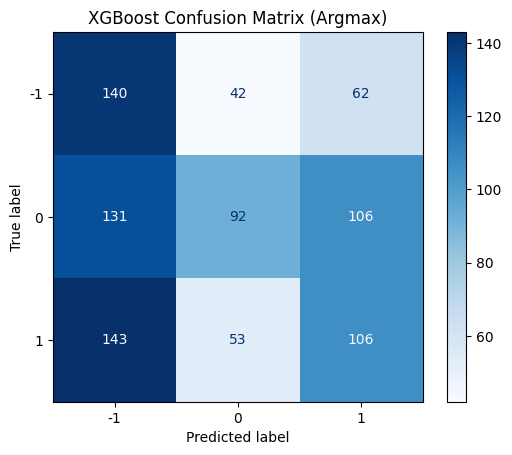

In [17]:
# Confusion matrix (3-class)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_xgb_label_encoder.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix (Argmax)')
plt.show()


In [ ]:
# Feature importance (use uncalibrated model since CalibratedClassifierCV doesn't expose feature_importances_)
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model_uncalibrated,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 14. Stage 6: LightGBM Signal Modelling


In [19]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")

# Prepare datasets for LightGBM using helper function
lgbm_prep = model_utils.prepare_lgbm_datasets(
    best_xgb_model=best_xgb_model,
    best_dataset=best_dataset,
    best_xgb_feature_columns=best_xgb_feature_columns,
    baseline_features=lgbm_baseline_features,
    target_column=cfg.TARGET_COLUMN,
    prediction_prefix="xgb"
)

signal_train_df = lgbm_prep["train_df"]
signal_val_df = lgbm_prep["val_df"]
signal_test_df = lgbm_prep["test_df"]
signal_feature_columns = lgbm_prep["signal_feature_columns"]
baseline_feature_columns = lgbm_prep["baseline_feature_columns"]
xgb_feature_names = lgbm_prep["xgb_feature_names"]

print("✓ Prepared LightGBM datasets with XGBoost features")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")
print(f"  XGBoost features added: {xgb_feature_names}")


✓ Prepared LightGBM datasets with XGBoost features
  Signal feature count: 7
  Baseline feature count: 3
  XGBoost features added: ['xgb_pred', 'xgb_prob_class0', 'xgb_prob_class1', 'xgb_prob_class2']


In [20]:
# Prepare and encode targets for LightGBM
target_prep = model_utils.prepare_lgbm_targets(
    train_df=signal_train_df,
    val_df=signal_val_df,
    test_df=signal_test_df,
    target_column=cfg.TARGET_COLUMN
)

y_train_signal = target_prep["y_train"]
y_val_signal = target_prep["y_val"]
y_test_signal = target_prep["y_test"]
label_encoder = target_prep["label_encoder"]

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [21]:
# Configure device for LightGBM
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(f"LightGBM device: {lgbm_device_config.get('description')} • backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • jobs={lgbm_device_config.get('n_jobs')}")

# Train both signal and baseline LightGBM models (class imbalance handled via is_unbalance=True and class_weight='balanced')
with profiling.StageProfiler("Stage 6: LightGBM Signal & Baseline Models", device_config):
    lgbm_results = model_utils.train_lightgbm_pair(
        signal_train_df=signal_train_df,
        signal_val_df=signal_val_df,
        signal_test_df=signal_test_df,
        signal_feature_columns=signal_feature_columns,
        baseline_feature_columns=baseline_feature_columns,
        y_train=y_train_signal,
        y_val=y_val_signal,
        y_test=y_test_signal,
        label_encoder=label_encoder,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        n_cv_splits=cfg.N_CV_SPLITS,
        cv_step_size=cfg.DEFAULT_EXPANDING_STEP,
        cv_min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE
    )

# Extract trained models and artifacts
signal_best_lgbm = lgbm_results["signal_model"]
baseline_best_lgbm = lgbm_results["baseline_model"]
signal_column_rename_map = lgbm_results["signal_column_rename_map"]
baseline_column_rename_map = lgbm_results["baseline_column_rename_map"]
lgbm_artifacts = lgbm_results["evaluation"]
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
LightGBM device: Apple MPS GPU • backend=cpu • jobs=6

[Stage ⏳] Stage 6: LightGBM Signal & Baseline Models — starting

TRAINING LIGHTGBM SIGNAL & BASELINE MODELS
Training SIGNAL model (baseline features + XGBoost predictions)...
✓ Signal model trained - Best CV macro-F1: 0.428
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Training BASELINE model (price/temporal features only)...
✓ Baseline model trained - Best CV macro-F1: 0.336
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Evaluating both models on validation and test sets...
✓ LightGBM validation performance
  Signal model  → Acc=0.438, Macro-F1=0.435
  Baseline model → Acc=0.411, Macro

In [22]:
# Evaluate both models using helper function
lgbm_artifacts = model_utils.evaluate_lgbm_models(
    signal_model=signal_best_lgbm,
    baseline_model=baseline_best_lgbm,
    signal_feature_columns=signal_feature_columns,
    baseline_feature_columns=baseline_feature_columns,
    val_df=signal_val_df,
    test_df=signal_test_df,
    y_val=y_val_signal,
    y_test=y_test_signal,
    label_encoder=label_encoder,
    signal_column_rename_map=signal_column_rename_map,
    baseline_column_rename_map=baseline_column_rename_map,
)

# Extract artifacts for later use
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]


✓ LightGBM validation performance
  Signal model  → Acc=0.438, Macro-F1=0.435
  Baseline model → Acc=0.411, Macro-F1=0.411


In [23]:
from sklearn.metrics import accuracy_score, f1_score

signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]

signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(
    f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}"
)
print(
    f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n"
)

# Use diagnostic function for detailed metrics
model_utils.print_class_wise_metrics(
    y_true=y_test_signal,
    y_pred=signal_test_pred,
    label_encoder=label_encoder,
    dataset_name="LightGBM SIGNAL Model - Test Set"
)

model_utils.print_class_wise_metrics(
    y_true=y_test_signal,
    y_pred=baseline_test_pred,
    label_encoder=label_encoder,
    dataset_name="LightGBM BASELINE Model - Test Set"
)


✓ LightGBM Test Performance
  Signal model  → Acc=0.373, Macro-F1=0.369
  Baseline model → Acc=0.403, Macro-F1=0.402


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set

Confusion Matrix:
[[ 80  57 107]
 [ 80 114 135]
 [ 84  86 132]]

Per-Class Recall:
  Class -1: 0.328 (80/244)
  Class 0: 0.347 (114/329)
  Class 1: 0.437 (132/302)

Classification Report:
              precision    recall  f1-score   support

          -1       0.33      0.33      0.33       244
           0       0.44      0.35      0.39       329
           1       0.35      0.44      0.39       302

    accuracy                           0.37       875
   macro avg       0.37      0.37      0.37       875
weighted avg       0.38      0.37      0.37       875


Predictions per class:
  Class -1: 244 predictions (27.9%)
  Class 0: 257 predictions (29.4%)
  Class 1: 374 predictions (42.7%)


CLASS-WISE METRICS: LightGBM BASELINE Model - Test Set

Confusion Matrix:
[[ 88 104  52]
 [ 60 140 129]
 [ 59 118 125]]

Per-C

In [24]:
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
statistical_results



STATISTICAL MODEL COMPARISON

Signal accuracy:   0.3726
Baseline accuracy: 0.4034

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       168
Only signal correct:       158
Only baseline correct:     185
Both models wrong:         364

Signal model correct:      326
Baseline model correct:    353

McNemar's χ² statistic:    1.9708
p-value:                   0.1604

✗ No significant difference between models (p >= 0.05)


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.3726 [0.3394, 0.4046]
Baseline model: 0.4027 [0.3703, 0.4332]
Difference:     -0.0301

○ Confidence intervals overlap - weaker evidence of difference




{'mcnemar_statistic': np.float64(1.9708454810495626),
 'mcnemar_p_value': np.float64(0.16035814751762545),
 'signal_acc_mean': np.float64(0.3725862857142857),
 'signal_acc_ci': (np.float64(0.3394285714285714),
  np.float64(0.4045714285714286)),
 'baseline_acc_mean': np.float64(0.4027222857142857),
 'baseline_acc_ci': (np.float64(0.3702857142857143),
  np.float64(0.43317142857142854))}

In [25]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Decode predictions for display
signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

# Compute test metrics
signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

# Display detailed class-wise metrics
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=signal_test_pred, label_encoder=label_encoder, dataset_name="LightGBM SIGNAL Model - Test Set")
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=baseline_test_pred, label_encoder=label_encoder, dataset_name="LightGBM BASELINE Model - Test Set")

✓ LightGBM Test Performance
  Signal model  → Acc=0.373, Macro-F1=0.369
  Baseline model → Acc=0.403, Macro-F1=0.402


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set

Confusion Matrix:
[[ 80  57 107]
 [ 80 114 135]
 [ 84  86 132]]

Per-Class Recall:
  Class -1: 0.328 (80/244)
  Class 0: 0.347 (114/329)
  Class 1: 0.437 (132/302)

Classification Report:
              precision    recall  f1-score   support

          -1       0.33      0.33      0.33       244
           0       0.44      0.35      0.39       329
           1       0.35      0.44      0.39       302

    accuracy                           0.37       875
   macro avg       0.37      0.37      0.37       875
weighted avg       0.38      0.37      0.37       875


Predictions per class:
  Class -1: 244 predictions (27.9%)
  Class 0: 257 predictions (29.4%)
  Class 1: 374 predictions (42.7%)


CLASS-WISE METRICS: LightGBM BASELINE Model - Test Set

Confusion Matrix:
[[ 88 104  52]
 [ 60 140 129]
 [ 59 118 125]]

Per-C

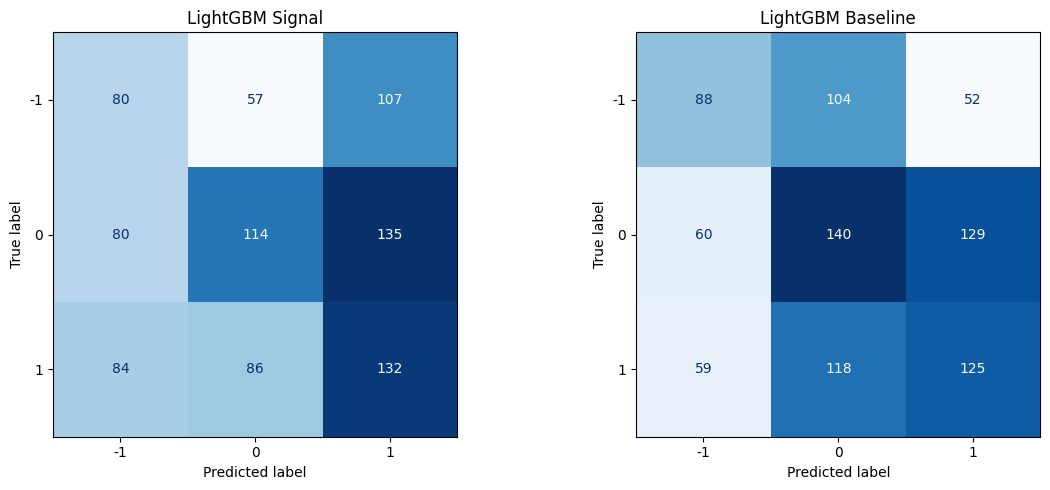

In [26]:
visualization.plot_confusion_matrices(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder,
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),3750.72,4.286537,19.008130,21.106647,22.206215,-352.17,66.343042,618
LightGBM Baseline (price-only),6383.08,7.294949,18.244865,37.422572,49.279560,-147.79,76.608187,513
Naive Buy-DA/Sell-Spot,1296.70,1.481943,21.178842,6.549095,8.348267,-1399.64,53.828571,875


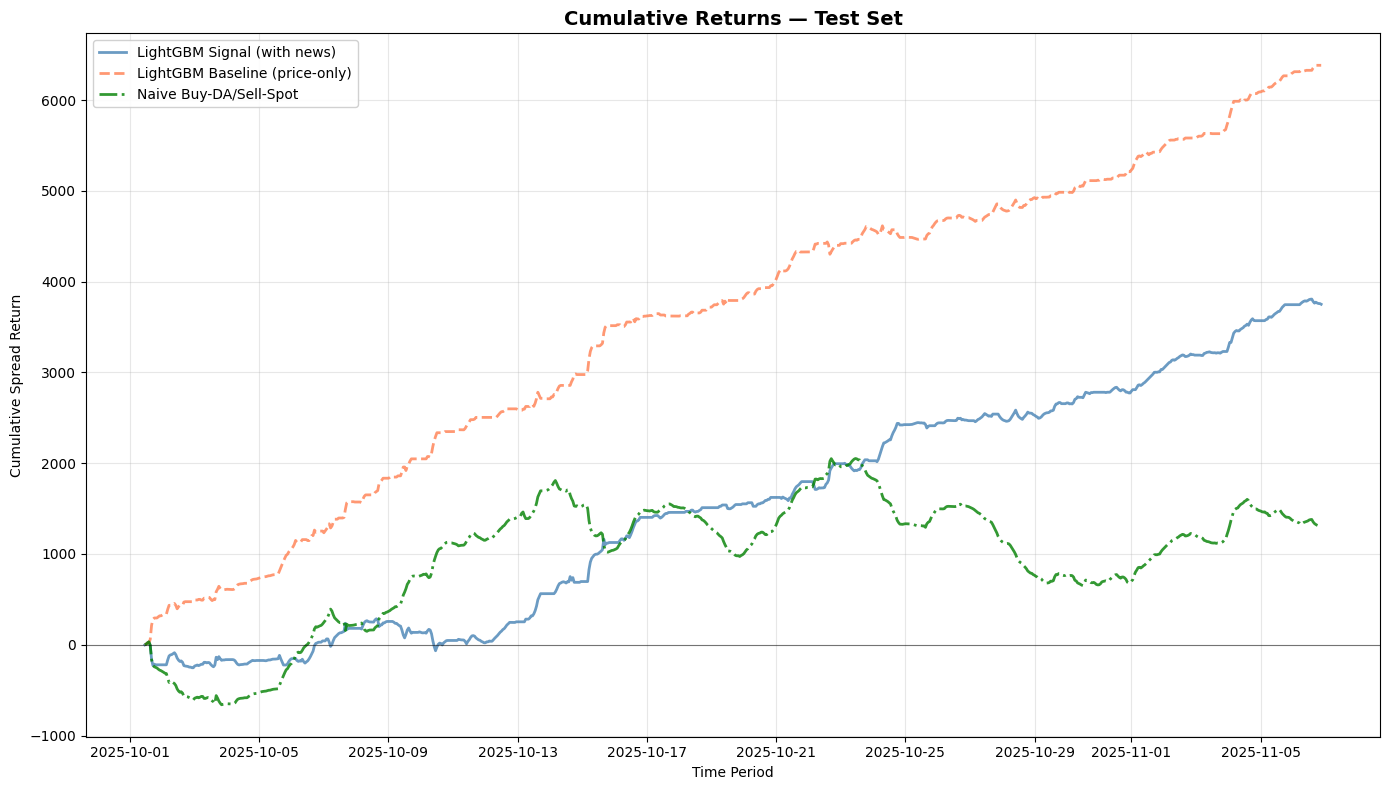

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [27]:
spot_col = evaluation.get_column_name([
    "Spot Price", "spot_price", "SpotPrice"
], signal_test_df)
day_ahead_col = evaluation.get_column_name([
    "Day Ahead Auction", "day_ahead_price", "DayAhead"
], signal_test_df)

if spot_col is None or day_ahead_col is None:
    raise KeyError("Could not identify spot or day-ahead price columns for backtesting.")

spot_series = signal_test_df[spot_col]
day_ahead_series = signal_test_df[day_ahead_col]
spread_series = spot_series - day_ahead_series

strategy_actions = {
    "LightGBM Signal (with news)": signal_test_decoded,
    "LightGBM Baseline (price-only)": baseline_test_decoded,
    "Naive Buy-DA/Sell-Spot": np.ones_like(signal_test_decoded, dtype=int),
}

strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)

display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


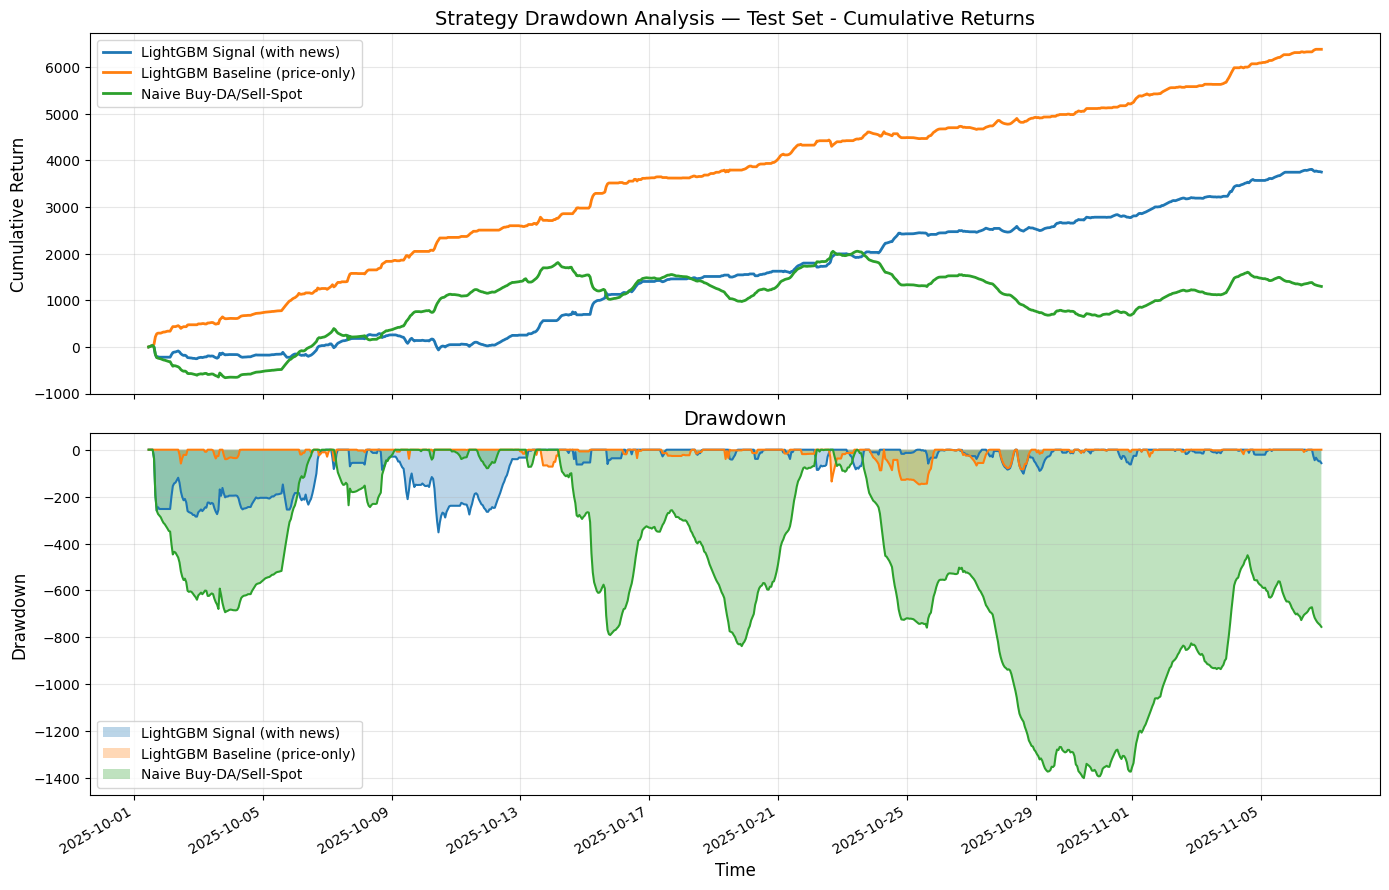

In [28]:
# Plot drawdown analysis
visualization.plot_drawdown_chart(
    returns_map=strategy_returns,
    title="Strategy Drawdown Analysis — Test Set"
)


,Total Return,Average Return,Volatility,Sharpe (annualised),Sortino (annualised),Max Drawdown,Win Rate (%),Number of Trades
Strategy,,,,,,,,
LightGBM Signal (with news),3750.72,4.286537,19.008130,21.106647,22.206215,-352.17,66.343042,618
LightGBM Baseline (price-only),6383.08,7.294949,18.244865,37.422572,49.279560,-147.79,76.608187,513
Naive Buy-DA/Sell-Spot,1296.70,1.481943,21.178842,6.549095,8.348267,-1399.64,53.828571,875


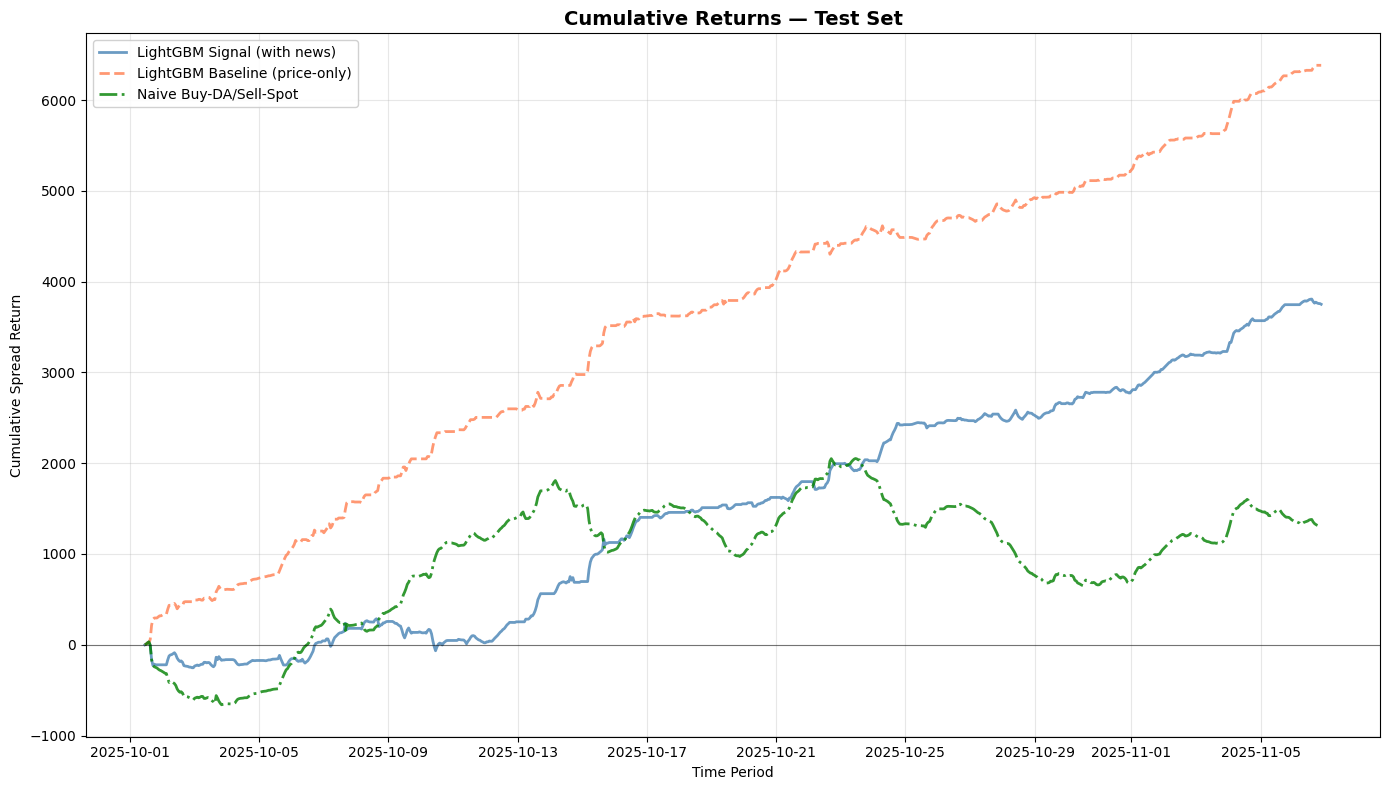

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Returns — Test Set'}, xlabel='Time Period', ylabel='Cumulative Spread Return'>)

In [29]:
# Setup backtest strategies
spread_series, strategy_actions = evaluation.setup_backtest_strategies(
    test_df=signal_test_df,
    signal_predictions=signal_test_pred,
    baseline_predictions=baseline_test_pred,
    label_encoder=label_encoder
)

# Compute and display strategy returns
strategy_returns = evaluation.compute_strategy_returns(strategy_actions, spread_series)
returns_summary = evaluation.summarise_strategy_set(strategy_returns)
display(returns_summary)

# Plot cumulative returns
visualization.plot_cumulative_returns(
    returns_map=strategy_returns,
    title="Cumulative Returns — Test Set",
    ylabel="Cumulative Spread Return",
)


BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          3750.72            21.106647             22.206215
LightGBM Baseline (price-only)       6383.08            37.422572             49.279560
Naive Buy-DA/Sell-Spot               1296.70             6.549095              8.348267

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          3441.72            19.400266             20.596598
LightGBM Baseline (price-only)       6126.58            36.079584             47.735385
Naive Buy-DA/Sell-Spot                859.20             4.3394

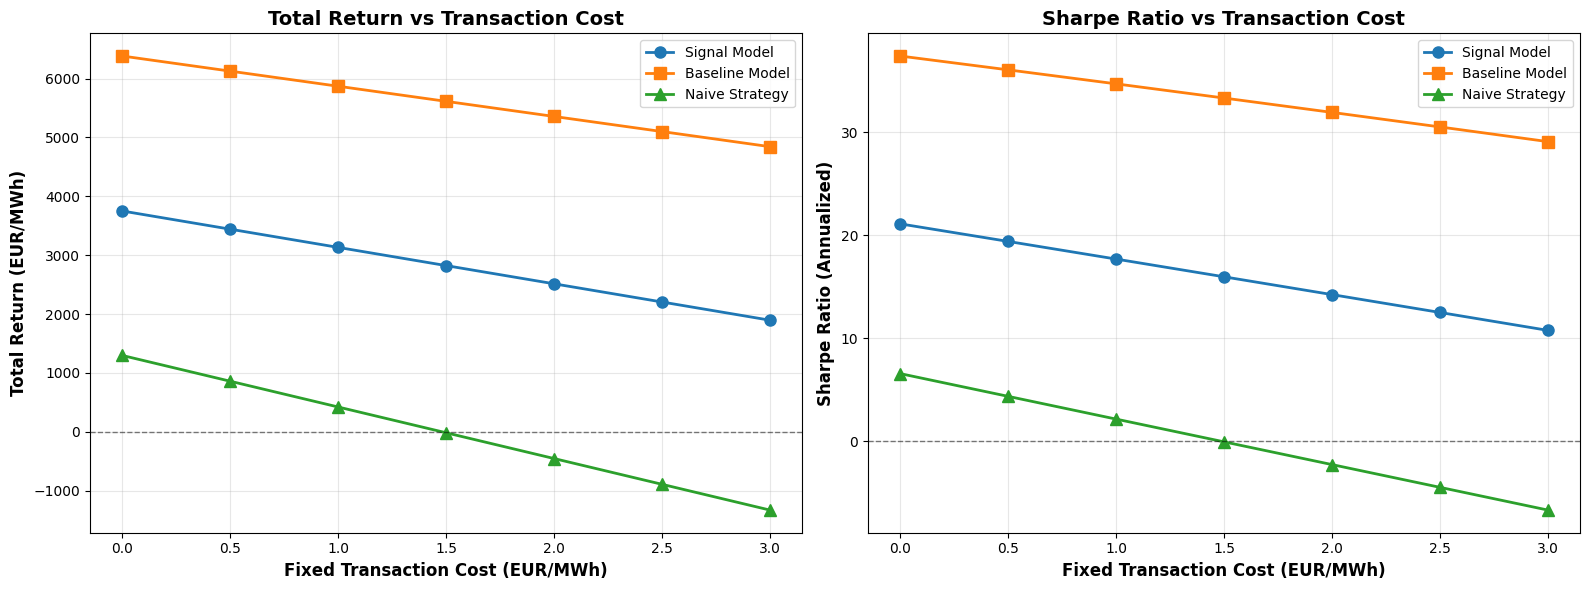

In [30]:
# Evaluate strategies with transaction costs
print("\n" + "=" * 80)
print("BACKTESTING WITH TRANSACTION COSTS")
print("=" * 80)

# Define transaction cost scenarios
transaction_cost_scenarios = {
    "No Costs": (0.0, 0.0),
    "Low Cost (€0.5/MWh)": (0.5, 0.0),
    "Medium Cost (€1.0/MWh)": (1.0, 0.0),
    "High Cost (€2.0/MWh + 0.1%)": (2.0, 0.001),
}

# Compute returns for each scenario
for scenario_name, (fixed_cost, pct_cost) in transaction_cost_scenarios.items():
    print(f"\n{scenario_name}:")
    print(f"  Fixed: €{fixed_cost}/MWh, Percentage: {pct_cost*100:.2f}%")
    
    strategy_returns_cost = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=fixed_cost,
        transaction_cost_pct=pct_cost
    )
    
    returns_summary_cost = evaluation.summarise_strategy_set(strategy_returns_cost)
    print(f"\n{returns_summary_cost[['Total Return', 'Sharpe (annualised)', 'Sortino (annualised)']].to_string()}")

# Visualize impact of transaction costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total return vs transaction cost
costs = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
signal_returns = []
baseline_returns = []
naive_returns = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    signal_returns.append(temp_returns["LightGBM Signal (with news)"].sum())
    baseline_returns.append(temp_returns["LightGBM Baseline (price-only)"].sum())
    naive_returns.append(temp_returns["Naive Buy-DA/Sell-Spot"].sum())

ax1.plot(costs, signal_returns, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax1.plot(costs, baseline_returns, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax1.plot(costs, naive_returns, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Total Return (EUR/MWh)', fontweight='bold', fontsize=12)
ax1.set_title('Total Return vs Transaction Cost', fontweight='bold', fontsize=14)
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# Right: Sharpe ratio vs transaction cost
signal_sharpes = []
baseline_sharpes = []
naive_sharpes = []

for cost in costs:
    temp_returns = evaluation.compute_strategy_returns(
        action_map=strategy_actions,
        spread=spread_series,
        transaction_cost=cost,
        transaction_cost_pct=0.0
    )
    temp_summary = evaluation.summarise_strategy_set(temp_returns)
    signal_sharpes.append(temp_summary.loc["LightGBM Signal (with news)", "Sharpe (annualised)"])
    baseline_sharpes.append(temp_summary.loc["LightGBM Baseline (price-only)", "Sharpe (annualised)"])
    naive_sharpes.append(temp_summary.loc["Naive Buy-DA/Sell-Spot", "Sharpe (annualised)"])

ax2.plot(costs, signal_sharpes, 'o-', linewidth=2, markersize=8, label='Signal Model')
ax2.plot(costs, baseline_sharpes, 's-', linewidth=2, markersize=8, label='Baseline Model')
ax2.plot(costs, naive_sharpes, '^-', linewidth=2, markersize=8, label='Naive Strategy')
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Fixed Transaction Cost (EUR/MWh)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Sharpe Ratio (Annualized)', fontweight='bold', fontsize=12)
ax2.set_title('Sharpe Ratio vs Transaction Cost', fontweight='bold', fontsize=14)
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)

# Feature importance for both models
signal_feature_columns_sanitized = list(signal_column_rename_map.values())
baseline_feature_columns_sanitized = list(baseline_column_rename_map.values())

visualization.plot_feature_importance(
    model=signal_best_lgbm,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
    top_n=20,
)
visualization.plot_feature_importance(
    model=baseline_best_lgbm,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
    top_n=20,
)

visualization.plot_feature_importance_shap(
    model=signal_best_lgbm,
    X_test=test_signal_X,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
)
visualization.plot_feature_importance_shap(
    model=baseline_best_lgbm,
    X_test=test_baseline_X,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
)



BACKTESTING WITH TRANSACTION COSTS

No Costs:
  Fixed: €0.0/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          3750.72            21.106647             22.206215
LightGBM Baseline (price-only)       6383.08            37.422572             49.279560
Naive Buy-DA/Sell-Spot               1296.70             6.549095              8.348267

Low Cost (€0.5/MWh):
  Fixed: €0.5/MWh, Percentage: 0.00%

                                Total Return  Sharpe (annualised)  Sortino (annualised)
Strategy                                                                               
LightGBM Signal (with news)          3441.72            19.400266             20.596598
LightGBM Baseline (price-only)       6126.58            36.079584             47.735385
Naive Buy-DA/Sell-Spot                859.20             4.3394

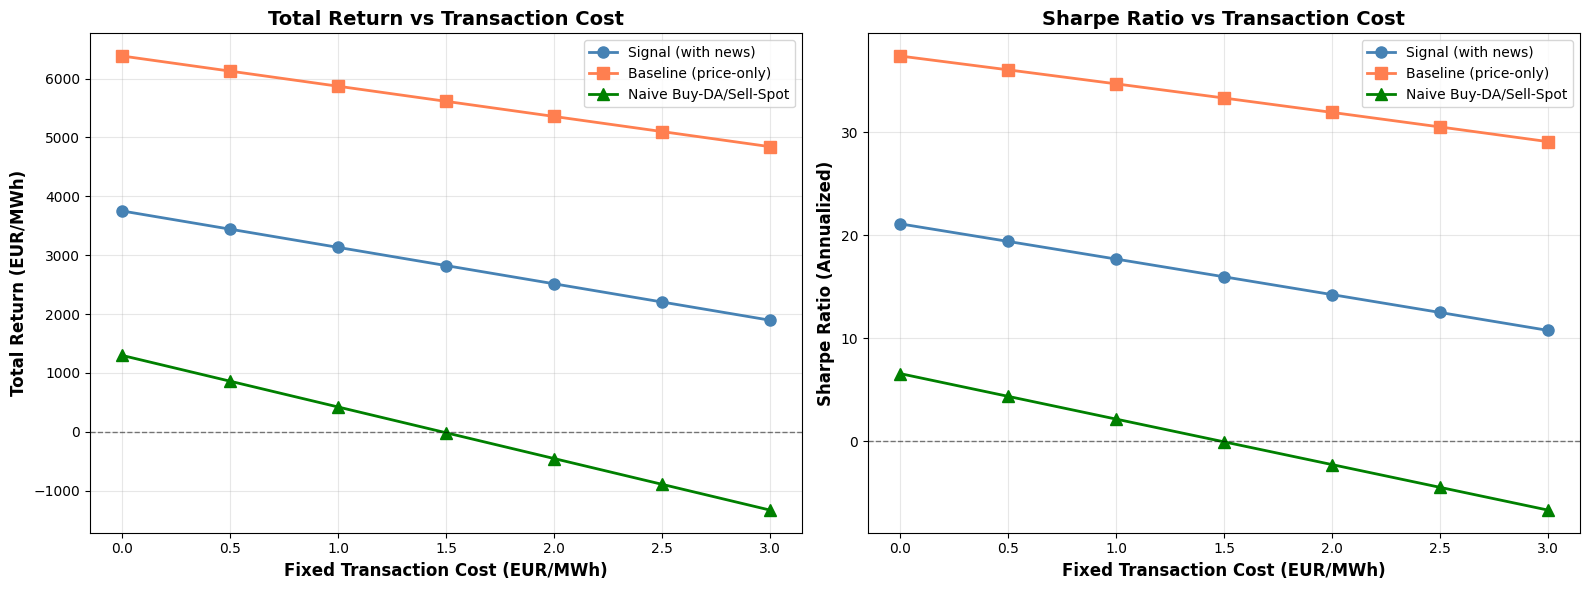

In [31]:
# Transaction cost sensitivity analysis
visualization.plot_transaction_cost_sensitivity(
    strategy_actions=strategy_actions,
    spread_series=spread_series
)